## SALES DATA ANALYSIS PROJECT

### STEP 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 2: Load Dataset

In [4]:
df = pd.read_csv(r"C:\Users\gayat\Downloads\VIT Downloads\Sales Analysis Project\Superstore.csv", encoding="latin1")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### STEP 2: Load Dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.shape

(9800, 18)

In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### STEP 4: Data Cleaning

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### STEP 5: Convert Date Columns

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

In [16]:
df[['Order Date','Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


### STEP 6: Create Month Column

In [17]:
df['Month'] = df['Order Date'].dt.month_name()

In [18]:
df[['Order Date','Month']].head()

,Order Date,Month
0,2017-11-08,November
1,2017-11-08,November
2,2017-06-12,June
3,2016-10-11,October
4,2016-10-11,October


### ANALYSIS 1: SALES BY CATEGORY

In [19]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64


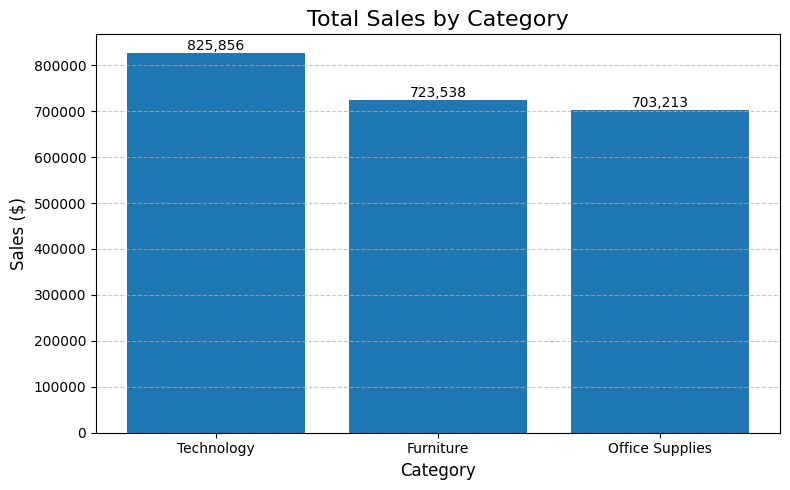

In [22]:
import matplotlib.pyplot as plt

# Calculate sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Create figure
plt.figure(figsize=(8,5))

# Plot
bars = plt.bar(category_sales.index, category_sales.values)

# Labels and title
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)

# Add values on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save chart
plt.savefig('category_sales.png')

plt.show()

### ANALYSIS 2: SALES BY REGION

In [23]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       710219.6845
East       660589.3560
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


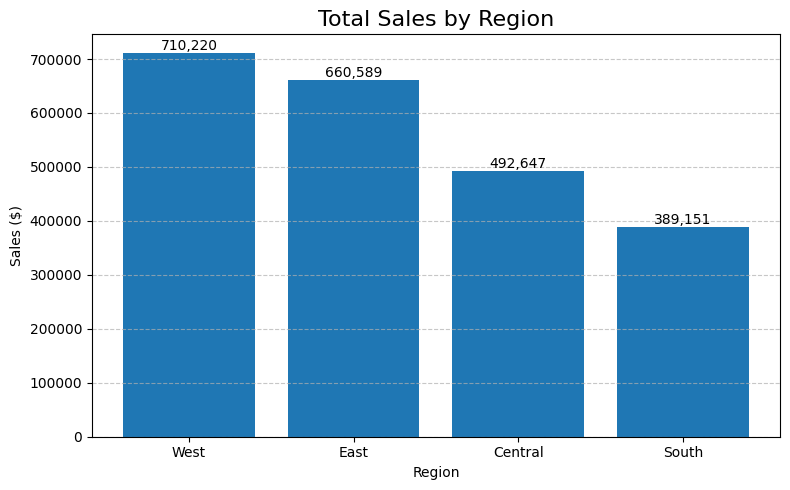

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(region_sales.index, region_sales.values)

plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Sales ($)')

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('region_sales.png')
plt.show()

In [ ]:
### ANALYSIS 3: MONTHLY SALES TREND

In [25]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

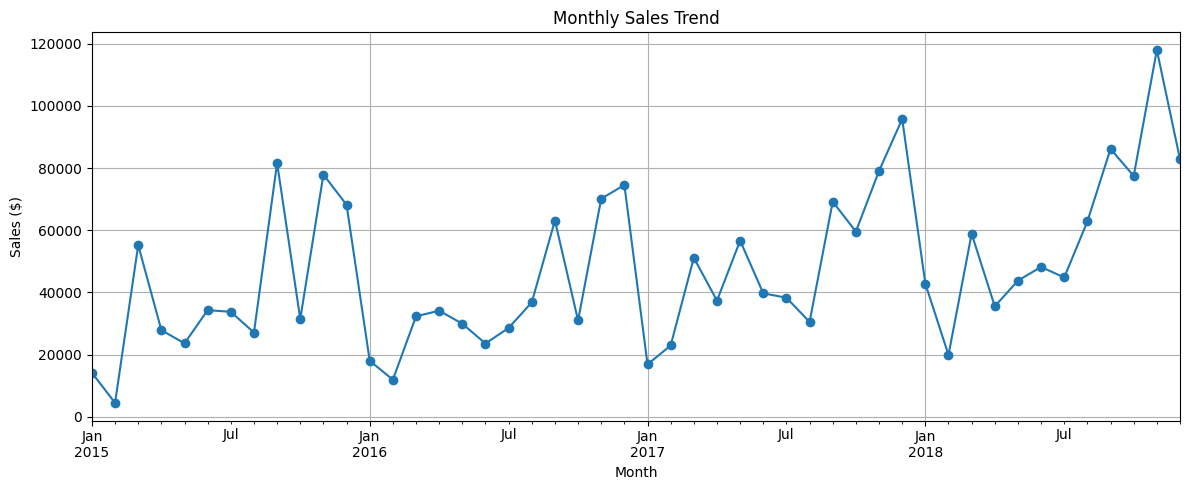

In [26]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)

plt.tight_layout()
plt.savefig('monthly_sales_trend.png')

plt.show()

### ANALYSIS 4: TOP 10 CITIES BY SALES

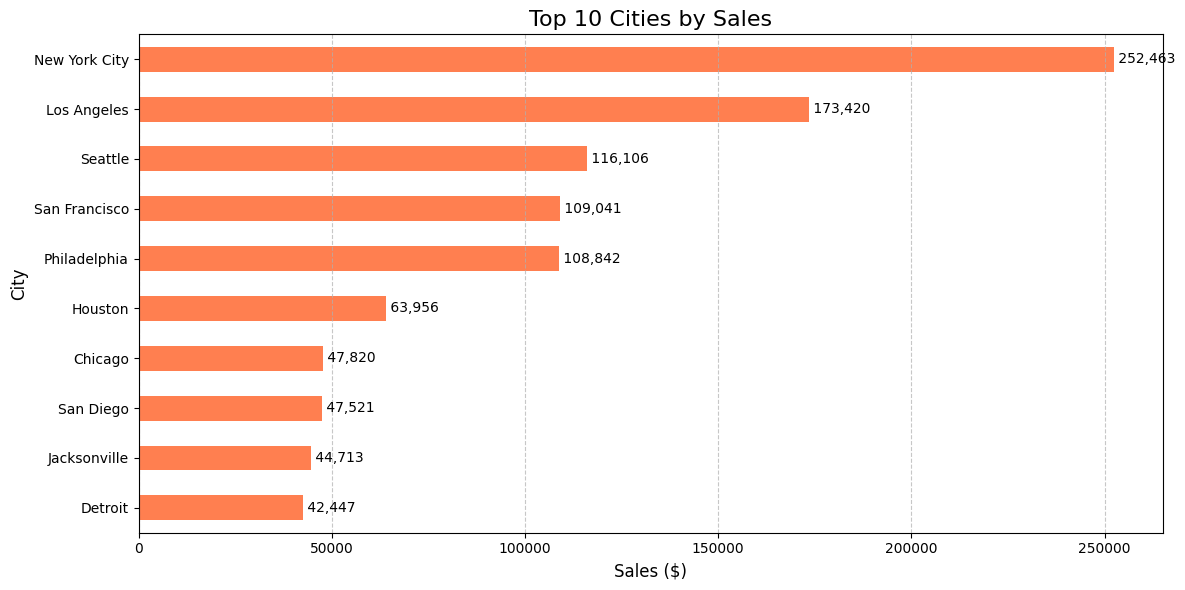

In [44]:
plt.figure(figsize=(12,6))

ax = city_sales.sort_values().plot(
    kind='barh',
    color='coral'   # different color to distinguish
)

plt.title('Top 10 Cities by Sales', fontsize=16)
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('City', fontsize=12)

for i, value in enumerate(city_sales.sort_values()):
    plt.text(
        value,
        i,
        f' {value:,.0f}',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('top_cities_sales.png', dpi=300)
plt.show()

### ANALYSIS 5: TOP 10 PRODUCTS


Top 10 Products
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


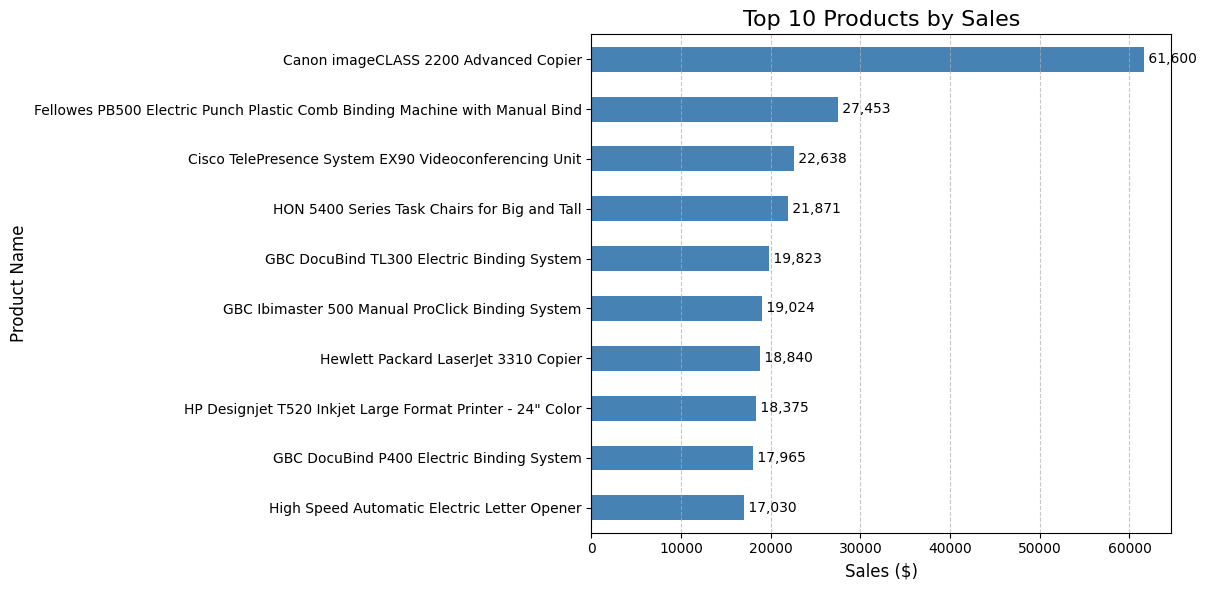

In [43]:
top_products = df.groupby('Product Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

print("\nTop 10 Products")
print(top_products)

plt.figure(figsize=(12,6))

ax = top_products.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

# Add value labels
for i, value in enumerate(top_products.sort_values()):
    plt.text(
        value,
        i,
        f' {value:,.0f}',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('top_products.png', dpi=300)

plt.show()

### PROJECT SUMMARY

In [38]:
print("\n========== PROJECT SUMMARY ==========")

print("\nTop Category:")
print(category_sales.idxmax())

print("\nTop Region:")
print(region_sales.idxmax())

print("\nTop City:")
print(city_sales.idxmax())

print("\nHighest Sales Month:")
print(monthly_sales.idxmax())

print("\nTop Product:")
print(top_products.idxmax())


========== PROJECT SUMMARY ==========

Top Category:
Technology

Top Region:
West

Top City:
New York City

Highest Sales Month:
2018-11

Top Product:
Canon imageCLASS 2200 Advanced Copier
